In [1]:
# Install packages
!pip install swig mediapy
!pip install mujoco==3.1.4
!pip install torch torchrl==0.8
!pip install gymnasium[box2d,mujoco]==0.28.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 36.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 30.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.9/420.9 kB 43.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 10.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error origi

# Imports and Functions

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.ndimage import rotate
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
import mediapy as media


# SLAM
SLAM is a famous problem in robotics that solves S(imultaneous) L(ocalization) A(nd) M(apping). Knowing our precise location in the world allows us to create an accurate map of our environment, while having an accurate map helps us to locate ourselves precisely. In SLAM, you have neither a map or a location but need to find both. This is what makes the problem hard and a lot of different solutions have been proposed.

In this section we are considering a simplified version of what an actual robot input might look like. You often have to tackle the SLAM problem with camera or LiDAR inputs, while we have taken the liberty to simplify down to a few noisy landmarks as well as noisy pose estimates. The robot walks a perfect circle, being surrounded by euqally spread out landmarks to its left and right.

The base theory of SLAM is in three steps:
1. Step one is to take the perception input and translate the landmarks to their best guess position, using the noisy pose update. This step is already implemented.
2. Step two is called the data association. Given the estimated landmark positions we have just retrieved and the landmarks that we already keep in our map, we want to determine whether an input landmark is a new one we have not seen thus far, or one that we already have in our map. If it is a new one, we can just add it, if it is a known one, we need to update the position of the one in the map and fuse the two.
3. Every sensor signal is inherently noisy, so just using the pose update as our new pose estimate will lead to compounding errors, which results in data drift. To mitigate this problem, we can use the positional shift that we have just calculated in our data association and use it to correct our noisy pose update.

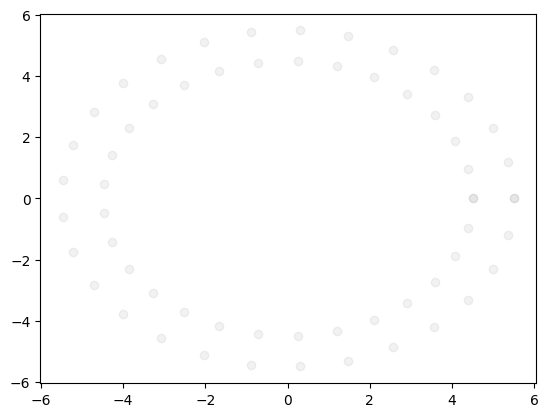

In [3]:
# Setup the SLAM environment
deg_to_rad = np.pi / 180.0
base_theta = deg_to_rad * 45

perception_mean = 0
pose_mean = 0

r = 5
t = np.linspace(0, 2*np.pi, 100)
t_features = np.linspace(0, 2*np.pi, 30)

triangle_rotation = 0
view_range = 10

base_triangle = [np.array([0, view_range]), np.array([view_range, 0])]


x = r * np.cos(t)
y = r * np.sin(t)

offset = 0.5

features_left = [(r - offset) * np.cos(t_features), (r - offset) * np.sin(t_features)]
features_right = [(r + offset) * np.cos(t_features), (r + offset) * np.sin(t_features)]

point_list = []
for i in range(len(features_left[0])):
    point_list.append((features_left[0][i], features_left[1][i]))
    point_list.append((features_right[0][i], features_right[1][i]))

fig, ax = plt.subplots()
gtx, gty = [], []
xmeas, ymeas = [], []
pose_estimate = []
slam_poses = []

features_gt_left, = ax.plot(features_left[0], features_left[1], 'o', c='grey', alpha=0.1)
features_gt_right, = ax.plot(features_right[0], features_right[1], 'o', c='grey', alpha=0.1)
triangle_plot, = ax.plot([], [], '-', c='r')
mes_plot, = ax.plot([], [], 'o', c='black')
gt, = ax.plot([], [],'--', c='g', alpha=0.1)
trajectory, = ax.plot([], [], '-', c="red", alpha = 1.0)
slam_map, = ax.plot([], [], 'o', c='purple')
slam_pose, = ax.plot([], [], 'o', c='blue')
slam_trajectory, = ax.plot([], [], '-', c='blue')

# Main drawing and update loop, should not be changed
def init():

    ax.set_xlim(-6.5, 6.5)
    ax.set_ylim(-6.5, 6.5)
    ax.set_xlabel('x position')
    ax.set_ylabel('y position')
    return gt, features_gt_left, features_gt_right, triangle_plot

def update(i):
    global gtx, gty, pose_estimate, slam, slam_poses
    if i == 0:
        gtx = []
        gty = []
        pose_estimate = []
        slam_poses = []
        slam.clear()

    angle = t[i]
    base_offset = np.array([x[i], y[i]])

    triangle = [base_offset + rot_matrix(base_theta + angle)@base_triangle[0], base_offset + rot_matrix(base_theta + angle)@base_triangle[1]]
    triangle_list = [list(base_offset), list(triangle[0]), list(triangle[1]), list(base_offset)]
    mes = perception(triangle_list[0], triangle_list[1], triangle_list[2], point_list, (x[i], y[i]))
    mes_for_plot = []
    for m in mes:
        mes_for_plot.append((m[0] + x[i], m[1] + y[i]))
    mes_plot.set_data([m[0] for m in mes_for_plot], [m[1] for m in mes_for_plot])
    pose_estimate.append((add_gaussian_noise(pose_mean, pose_std_deviation, (x[i], y[i]))))


    triangle_plot.set_data([i[0] for i in triangle_list], [i[1] for i in triangle_list])
    gtx.append(x[i])
    gty.append(y[i])
    gt.set_data(gtx, gty)
    trajectory.set_data([p[0] for p in pose_estimate], [p[1] for p in pose_estimate])

    pose_update = ()
    if len(pose_estimate) == 1:
        pose_update = (pose_estimate[-1][0] - 5, pose_estimate[-1][1])
    else:
        pose_update = (pose_estimate[-1][0] - pose_estimate[-2][0], pose_estimate[-1][1] - pose_estimate[-2][1])

    new_map, new_slam_pose = slam.iterate(mes, pose_update)

    slam_map.set_data([i[0] for i in new_map], [i[1] for i in new_map])
    slam_pose.set_data([new_slam_pose[0]], [new_slam_pose[1]])

    slam_poses.append(new_slam_pose)
    slam_trajectory.set_data([i[0] for i in slam_poses], [i[1] for i in slam_poses])

    return gt, features_gt_left, features_gt_right, triangle_plot, mes_plot, trajectory, slam_map, slam_pose, slam_trajectory

In [4]:
# Parameters: Lower these to make the perception and pose more stable, up them to test for stability
percetion_std_deviation = 0.05
pose_std_deviation = 0.05

In [5]:
# Helper functions to create guassian noise for perception and pose inputs
def add_gaussian_noise(mean, std, point):
    noise = np.random.normal(mean, std, 2)
    noisey_point = (noise[0] + point[0], noise[1] + point[1])
    return noisey_point

def rot_matrix(theta):
    rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])

    return rot_matrix

def sign(p1, p2, p3):
    return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])


def PointInTriangle (pt, v1, v2, v3):
    d1 = sign(pt, v1, v2)
    d2 = sign(pt, v2, v3)
    d3 = sign(pt, v3, v1)

    has_neg = (d1 < 0) or (d2 < 0) or (d3 < 0)
    has_pos = (d1 > 0) or (d2 > 0) or (d3 > 0)

    return not(has_neg and has_pos)

def perception(v1, v2, v3, point_list, gt_pose):
    global perception_mean, percetion_std_deviation
    out = []
    for point in point_list:
        if PointInTriangle(point, v1, v2, v3):
            out.append(add_gaussian_noise(perception_mean, percetion_std_deviation, (point[0] - gt_pose[0], point[1] - gt_pose[1])))

    return out

In [6]:
## Solution
# SLAM class to handle the inputs and create a map in which we are locating ourselfes
class SLAM:
    def __init__(self):
        self.map = []
        self.visited = []
        self.pose_estimate = ()
        self.threshold_distance = 0.5
        self.interpolation = 0.8
        self.pose_estimate = (5, 0)
        self.feature_differences = []
        self.pose_x = 5
        self.pose_y = 0
        self.cov_x = 0
        self.cov_y = 0

    def nearest_neighbour(self, point):
        smallest_dist = 99999999999
        index = None
        for i in range(len(self.map)):
            if i in self.visited:
                continue
            dis = (self.map[i][0] - point[0], self.map[i][1] - point[1])
            distance = np.sqrt(dis[0]**2 + dis[1]**2)
            if (distance < smallest_dist) and (distance < self.threshold_distance):
                index = i
                smallest_dist = distance

        if index is not None:
            self.visited.append(index)
        return index

    def lerp(self, p1, p2):
        influence = 0.5
        interpolated_point = (self.interpolation * p1[0] + (1.0 - self.interpolation) * p2[0], self.interpolation * p1[1] + (1.0 - self.interpolation) * p2[1])
        self.feature_differences.append((influence * (p1[0] - p2[0]), influence * (p1[1] - p2[1])))
        return interpolated_point


    def data_association(self, perception, pose):
        predicted_perception = []
        new_map = []
        for p in perception:
            predicted_perception.append((p[0] + pose[0], p[1] + pose[1]))

        for p in predicted_perception:
            neighbour_i = self.nearest_neighbour(p)
            if neighbour_i is None:
                self.map.append(p)
            else:
                neighbour = self.map[neighbour_i]
                new_point = self.lerp(p, neighbour)
                new_map.append(new_point)

        for i in range(len(self.visited)):
            self.map[self.visited[i]] = new_map[i]

        self.visited = []

    def update(self, pose):
        if len(self.feature_differences) == 0:
            self.pose_estimate = (self.pose_estimate[0] + pose[0], self.pose_estimate[1] + pose[1])
            return

        x = 0
        y = 0
        for i in range(len(self.feature_differences)):
            x += self.feature_differences[i][0]
            y += self.feature_differences[i][1]

        x /= len(self.feature_differences)
        y /= len(self.feature_differences)


        R = pose_std_deviation ** 2 # covariance of state transition = cov imu
        Q = percetion_std_deviation ** 2 / len(self.feature_differences) # covariance of measurement noise = cov position from landmark

        (self.pose_x, self.cov_x)= self.KallmanFilter(self.pose_x, self.cov_x, pose[0], self.pose_estimate[0] + pose[0] - x, R, Q)
        (self.pose_y, self.cov_y)= self.KallmanFilter(self.pose_y, self.cov_y, pose[1], self.pose_estimate[1] + pose[1] - y, R, Q)

        self.pose_estimate = (self.pose_x, self.pose_y)
        self.feature_differences = []

    def KallmanFilter(self, my_old, signma_old, control_current, observation_current, R, Q):
        A = 1
        B = 1
        C = 1
        my_temp = A*my_old + B * control_current # new pos = old pos + imu
        simga_temp = A *  signma_old * A + R # new cov = old cov + noise of imu
        K = simga_temp * C * 1/(C * simga_temp*C + Q)
        my_new = my_temp + K * (observation_current-C*my_temp)
        sigma_new = (1-K*C)*simga_temp
        return my_new, sigma_new

    def iterate(self, perception, pose):
        pose_estimate = (self.pose_estimate[0] + pose[0], self.pose_estimate[1] + pose[1])
        self.data_association(perception, pose_estimate)
        self.update(pose)

        return self.map, self.pose_estimate

    def clear(self):
        self.map = []
        self.pose_estimate = (5, 0)


In [7]:
slam = SLAM()

ani = FuncAnimation(fig, update, len(t),
                    init_func=init, blit=True, interval=100)
plt.show()
HTML(ani.to_html5_video())

## Tasks
1. Create a nearest neighbour search to find the nearest neighbour of a perception landmark to a map landmark. Based on a threshold we set, we can now determine whether the landmark is new or belongs to one already in the map.
2. Write the data association given the list of neighbours you have just found. The neighbours should be fused together and the positional shift should be tracked for the later update step. We recommend keeping it simple, fusing the positions given a 80%-20% linear interpolation.
3. Having completed the data association, we can now use the positional shift for a pose correction, completing our first SLAM algorithm.

## Homework
In the beginning of the practice we have talked about Kalman Filters and how they can be used to fuse noisy sensor data in order to better estimate the true update. This can be directly applied here, taking the Kalman Filter a step further and implementing it into the:
- Update step in order to fuse the pose estimate and SLAM pose correction
- Using a separate Kalman filter per cone and therefore replacing the data association with Kalman filters

# Learning to remove noise
We have seen that we can use a Kalman filter (there exist more advanced filters, such as particle filters, extended Kalman filters, or unscented Kalman filters) to deal with noisy measurements, when we have a good model of our world. However, it might also be a good idea to learn how to remove noise from observations; especially, if we do not have a good model of the dynamics of our world or of the noise we are dealing with.

## Denoising Auto-Encoders
Denoising autoencoders are a type of neural network architecture used for unsupervised learning tasks, particularly in the field of image and signal processing. The main objective of denoising autoencoders is to remove noise or unwanted variations from input data, reconstructing a clean version of the original input. This is achieved by training the autoencoder to encode the noisy input into a lower-dimensional representation and then decode it back to the original input, minimizing the reconstruction error. By learning to denoise the data, denoising autoencoders can effectively capture the underlying structure and patterns in the data, making them useful for tasks such as image denoising, anomaly detection, and feature extraction.

In [8]:
# The denoising Autoencoder model
class DenoisingAutoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super(DenoisingAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),#1x28x28 -> 16x14x14
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),#16x14x14 -> 8x7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(8 * 7 * 7, 64),#8x7x7 -> 64
            nn.ReLU(),
            nn.Linear(64, latent_dim)#64 -> latent_dim
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),#latent_dim -> 64
            nn.ReLU(),
            nn.Linear(64, 8 * 7 * 7),#64 -> 8x7x7
            nn.ReLU(),
            nn.Unflatten(1, (8, 7, 7)),
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),#8x7x7 -> 16x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),#16x14x14 -> 1x28x28
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [9]:
# Load the MNIST dataset
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 400kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.29MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]


In [10]:
# Create the denoising autoencoder model
latent_dim =2
model = DenoisingAutoencoder(latent_dim).to(device)

# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    train_loss = 0.0
    # Training
    model.train()
    for images, _ in train_loader:
        images = images.to(device)
        # Add random noise to the input images
        noise = torch.randn_like(images)
        noisy_images = images + 0.2 * noise

        # Forward pass
        outputs = model(noisy_images)

        # Compute the loss
        loss = criterion(outputs, images)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss / len(train_dataset):.4f}")

Epoch 1/50, Training Loss: 0.0798
Epoch 2/50, Training Loss: 0.0569
Epoch 3/50, Training Loss: 0.0540
Epoch 4/50, Training Loss: 0.0514
Epoch 5/50, Training Loss: 0.0500
Epoch 6/50, Training Loss: 0.0490
Epoch 7/50, Training Loss: 0.0481
Epoch 8/50, Training Loss: 0.0475
Epoch 9/50, Training Loss: 0.0469
Epoch 10/50, Training Loss: 0.0465
Epoch 11/50, Training Loss: 0.0461
Epoch 12/50, Training Loss: 0.0457
Epoch 13/50, Training Loss: 0.0454
Epoch 14/50, Training Loss: 0.0451
Epoch 15/50, Training Loss: 0.0449
Epoch 16/50, Training Loss: 0.0447
Epoch 17/50, Training Loss: 0.0445
Epoch 18/50, Training Loss: 0.0442
Epoch 19/50, Training Loss: 0.0439
Epoch 20/50, Training Loss: 0.0437
Epoch 21/50, Training Loss: 0.0434
Epoch 22/50, Training Loss: 0.0432
Epoch 23/50, Training Loss: 0.0430
Epoch 24/50, Training Loss: 0.0428
Epoch 25/50, Training Loss: 0.0427
Epoch 26/50, Training Loss: 0.0425
Epoch 27/50, Training Loss: 0.0424
Epoch 28/50, Training Loss: 0.0422
Epoch 29/50, Training Loss: 0

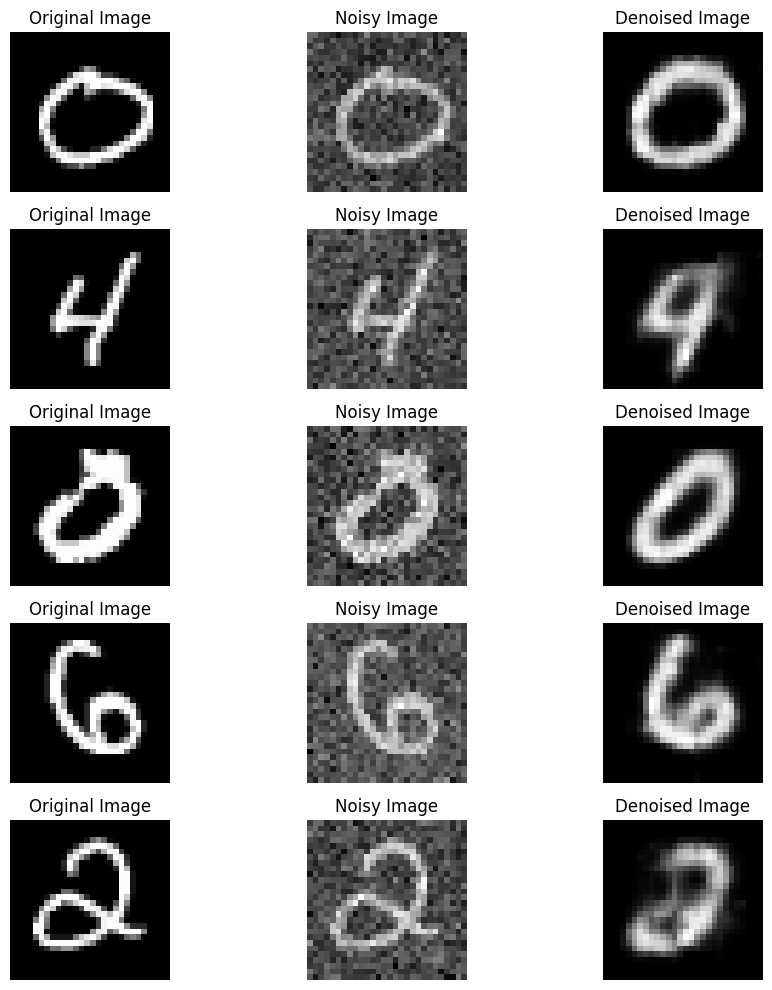

In [12]:
# Set the number of images to denoise and display
num_images = 5

# Denoise and display the images
fig, axes = plt.subplots(num_images, 3, figsize=(10, 10))

for i in range(num_images):
    # Get the original image
    original_image = train_dataset[np.random.randint(0,len(train_dataset))][0].squeeze().numpy()

    # Add noise to the image
    noise = torch.randn_like(torch.tensor(original_image))
    noisy_image = original_image + 0.2 * noise.squeeze().numpy()

    # Denoise the image using the trained autoencoder
    denoised_image = model(torch.Tensor(noisy_image).to(device).unsqueeze(0).unsqueeze(0)).squeeze().cpu().detach().numpy()

    # Plot the original and denoised images side by side
    axes[i, 0].imshow(original_image, cmap='gray')
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(noisy_image, cmap='gray')
    axes[i, 1].set_title('Noisy Image')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(denoised_image, cmap='gray')
    axes[i, 2].set_title('Denoised Image')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

## Latent Spaces
We have seen the ability of the denoising autoenoder to remove noise from noisy images. This is very useful if we have corrupted images. In particular, this not only works with Gaussian noise, but also when we have a part of the image occluded.

Another nice property of (all) autoencoders is their ability to encode a high dimensional input space (e.g., an image) into a lower dimensional latent space. By being forced to compress all information into the bottleneck in the neural network

Latent spaces capture the underlying structure and patterns in the data by representing it in a compressed form. In the context of reinforcement learning, latent spaces offer several benefits. By encoding the high dimensional input space into a lower dimensional latent space, the complexity of the environment is reduced, making it easier for the agent to learn and generalize. Latent spaces also enable the discovery of meaningful representations and features, which can aid in the extraction of relevant information for decision-making. Additionally, the compact representation provided by latent spaces can improve the efficiency of reinforcement learning algorithms by reducing the computational and memory requirements. Overall, latent spaces play a crucial role in reinforcement learning by facilitating efficient representation learning and enhancing the agent's ability to understand and interact with the environment.

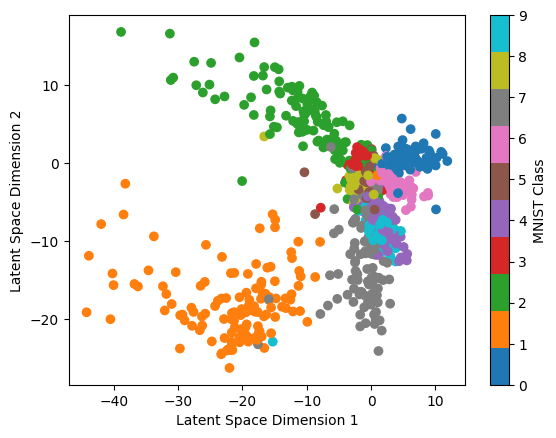

In [13]:
# Get the latent vectors for the first 1000 images in the test set
images = torch.stack([test_dataset[i][0] for i in range(1000)], dim=0)
labels = test_dataset.targets[:1000]
latent_vectors = model.encoder(images.to(torch.float32).to(device)).cpu().detach().numpy()

# Plot the latent spaces with color indicating the classes
plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=labels, cmap='tab10')
plt.colorbar(label='MNIST Class')

# Add labels and title
plt.xlabel('Latent Space Dimension 1')
plt.ylabel('Latent Space Dimension 2')

# Show the plot
plt.show()

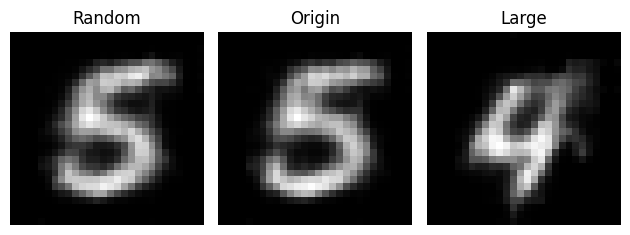

In [14]:
## Solution
latent_vector = torch.randn((1, latent_dim)).to(device)
fig, [ax1, ax2, ax3] = plt.subplots(1, 3)

ax1.imshow(model.decoder(latent_vector).cpu().detach().numpy().squeeze(), cmap='gray')
ax1.set_title('Random')
ax1.axis('off')

ax2.imshow(model.decoder(torch.zeros((1, latent_dim)).to(device)).cpu().detach().numpy().squeeze(), cmap='gray')
ax2.set_title('Origin')
ax2.axis('off')

ax3.imshow(model.decoder(10*latent_vector).cpu().detach().numpy().squeeze(), cmap='gray')
ax3.set_title('Large')
ax3.axis('off')

plt.tight_layout()
plt.show()


### Tasks
1. Analyse the latent space. Which classes seem to be easy to to distinguish, which ones are close together in latent space?
2. Autoencoders are so-called generative models, because we can create new examples by choosing a point in latent space and using the decoder to generate an image from it. Write code to generate new images. You can play around with the vector in latent space. What happens when we choose a vector close to the origin/in a region where there is just one class/in an uninhabited region of the latent space (where none of the latent space vectors reside in our visualization)?
3. We here use 2-dimensional latent space that is great for visualizing it but not that great for performance. Recode the NN to find a good tradeoff between dimensionality of your latent space and quality of reconstruction.

# Variational Autoencoders (VAEs)

In the previous section we used a **deterministic** denoising autoencoder: each image maps to a single point in latent space. **Variational Autoencoders (VAEs)** extend this idea by mapping each input to a *distribution* in latent space (typically a Gaussian, parameterized by mean and variance). Sampling from that distribution lets us generate diverse outputs while a **KL divergence** term regularizes the latent space toward a standard normal prior.

Compared to the denoising autoencoder, VAEs emphasize a smooth, continuous latent space suitable for generation and interpolation. The exercises below let you compare both models directly on MNIST.

### Key concepts

- **Probabilistic Latent Space:**  
    Unlike standard autoencoders that map inputs to fixed points in the latent space, VAEs map inputs to a distribution (typically Gaussian) in the latent space. Each input is encoded as a mean and variance, allowing for sampling and generating diverse outputs.

- **Encoder and Decoder:**  
    The encoder network learns to approximate the posterior distribution of the latent variables given the input data. The decoder network reconstructs the input from samples drawn from the latent distribution.

- **Reparameterization Trick:**  
    To enable backpropagation through the stochastic sampling process, VAEs use the reparameterization trick, expressing the sampling operation as a deterministic function of the mean, variance, and a random noise variable.

- **Loss Function:**  
    The VAE loss combines two terms:
    1. **Reconstruction Loss:** Measures how well the decoder reconstructs the input from the latent code (often using binary cross-entropy or mean squared error).
    2. **KL Divergence:** Regularizes the learned latent distribution to be close to a standard normal distribution, encouraging smoothness and continuity in the latent space.

## Why Use VAEs?

- **Generative Modeling:**  
    VAEs can generate new, realistic samples by sampling from the latent space and decoding them, making them useful for tasks like image synthesis and data augmentation.

- **Structured Latent Space:**  
    The regularization encourages the latent space to be continuous and interpretable, allowing for smooth interpolation between data points and meaningful manipulations.

- **Uncertainty Quantification:**  
    By modeling distributions rather than points, VAEs can capture uncertainty in the data and generate diverse outputs.

## Training the VAE

We reuse the same MNIST loaders and device from the denoising autoencoder section.


In [15]:
## Solution
# Define the VAE model.
class VAE(nn.Module):
	def __init__(self, latent_dim, input_shape=(1, 28, 28)):
		super(VAE, self).__init__()
		flatten_dim = 8 * input_shape[1]//4 * input_shape[2]//4

		self.encoder = nn.Sequential(
            nn.Conv2d(input_shape[0], 16, kernel_size=3, stride=2, padding=1),#1x28x28 -> 16x14x14
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),#16x14x14 -> 8x7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(flatten_dim, 64),#8x7x7 -> 64
            nn.ReLU(),
            nn.Linear(64, 2*latent_dim)#64 -> 2*latent_dim
        )

		self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),#latent_dim -> 64
            nn.ReLU(),
            nn.Linear(64, flatten_dim),#64 -> 8x7x7
            nn.ReLU(),
            nn.Unflatten(1, (8, input_shape[1] // 4, input_shape[2] // 4)), #8x7x7 -> 8x7x7
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),#8x7x7 -> 16x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, input_shape[0], kernel_size=3, stride=2, padding=1, output_padding=1),#16x14x14 -> 1x28x28
            nn.Sigmoid()
        )

	def encode(self, x):
		h = self.encoder(x)
		mu, log_var = torch.chunk(h, 2, dim=1)  # Split into mean and log variance
		return mu, log_var

	def reparameterize(self, mu, log_var):
		std = torch.exp(0.5 * log_var)
		eps = torch.randn_like(std)
		z = mu + eps * std
		return z

	def decode(self, z):
		return self.decoder(z)

	def forward(self, x):
		mu, log_var = self.encode(x)
		z = self.reparameterize(mu, log_var)
		x_hat = self.decode(z)
		return x_hat, mu, log_var

# Define the loss function.
def vae_loss(x, x_hat, mu, log_var):
	reconstruction_loss = nn.BCELoss(reduction='sum')(x_hat, x)
	kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
	return reconstruction_loss + kl_divergence



In [16]:
# Initialize VAE model
latent_dim = 2
vae = VAE(latent_dim).to(device)

# Define optimizer
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# Training loop
num_epochs = 50
for epoch in range(num_epochs):
	total_loss = 0
	for batch_idx, (data, _) in enumerate(train_loader):
		data = data.to(device)

		optimizer.zero_grad()
		recon_batch, mu, log_var = vae(data)
		loss = vae_loss(data, recon_batch, mu, log_var)
		loss.backward()
		total_loss += loss.item()
		optimizer.step()

	print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {total_loss/len(train_loader.dataset):.4f}")

Epoch 1/50, Average Loss: 224.2066
Epoch 2/50, Average Loss: 179.2763
Epoch 3/50, Average Loss: 170.3783
Epoch 4/50, Average Loss: 166.2457
Epoch 5/50, Average Loss: 163.7099
Epoch 6/50, Average Loss: 162.1152
Epoch 7/50, Average Loss: 160.5941
Epoch 8/50, Average Loss: 159.6304
Epoch 9/50, Average Loss: 158.8611
Epoch 10/50, Average Loss: 158.3159
Epoch 11/50, Average Loss: 157.7908
Epoch 12/50, Average Loss: 157.4067
Epoch 13/50, Average Loss: 156.9521
Epoch 14/50, Average Loss: 156.5514
Epoch 15/50, Average Loss: 156.2239
Epoch 16/50, Average Loss: 155.7338
Epoch 17/50, Average Loss: 155.4014
Epoch 18/50, Average Loss: 155.0728
Epoch 19/50, Average Loss: 154.8136
Epoch 20/50, Average Loss: 154.5873
Epoch 21/50, Average Loss: 154.3583
Epoch 22/50, Average Loss: 154.1553
Epoch 23/50, Average Loss: 153.9120
Epoch 24/50, Average Loss: 153.7699
Epoch 25/50, Average Loss: 153.6057
Epoch 26/50, Average Loss: 153.4789
Epoch 27/50, Average Loss: 153.3047
Epoch 28/50, Average Loss: 153.1130
E

### Tasks
1. Finish the VAE code.

## VAE Latent Space

After training, encode test images with `vae.encode` and plot the 2D latent space. Compare this scatter plot with the denoising autoencoder plot above: the KL term encourages latents to stay close to a standard normal distribution.


Mean of latent vectors: [ 0.03800925 -0.04121476]
Standard deviation of latent vectors: [1.0262982 1.046509 ]


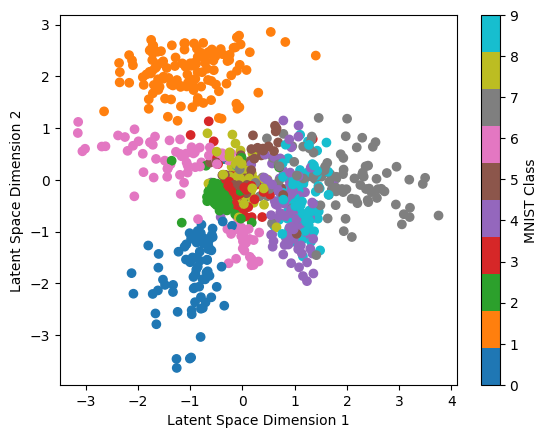

In [17]:
# Get the latent vectors for the first 1000 images in the test set
images = torch.stack([test_dataset[i][0] for i in range(1000)], dim=0)
labels = test_dataset.targets[:1000]
latent_vectors = vae.encode(images.to(dtype=torch.float32,device=device))[0].cpu().detach().numpy()

# Compute mean and standard deviation of the latent vectors
mean_latent = np.mean(latent_vectors, axis=0)
std_latent = np.std(latent_vectors, axis=0)
print(f"Mean of latent vectors: {mean_latent}")
print(f"Standard deviation of latent vectors: {std_latent}")

# Plot the latent spaces with color indicating the classes
plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=labels, cmap='tab10')
plt.colorbar(label='MNIST Class')

# Add labels and title
plt.xlabel('Latent Space Dimension 1')
plt.ylabel('Latent Space Dimension 2')

# Show the plot
plt.show()

## Reconstruction of images from the latent space.

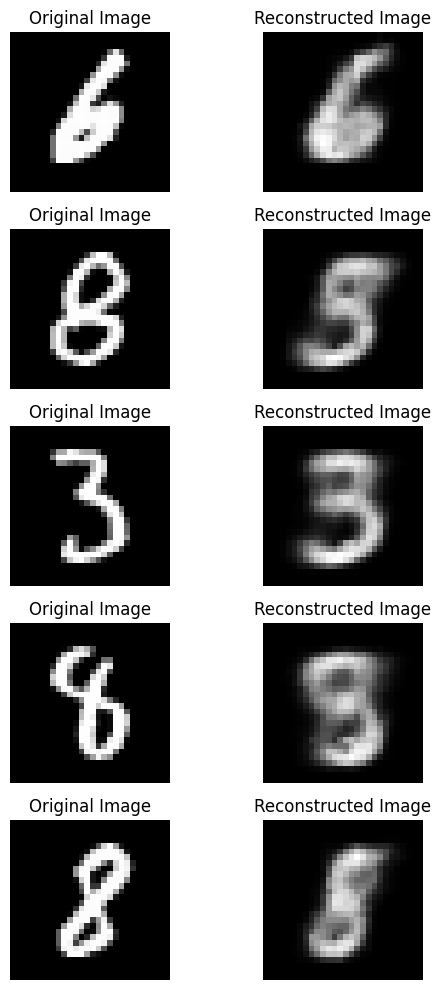

In [18]:
# Number of images to reconstruct and display
num_images = 5

# Reconstruct and display the images
fig, axes = plt.subplots(num_images, 2, figsize=(6, 10))

for i in range(num_images):
    # Get the original image
    original_image = train_dataset[np.random.randint(0,len(train_dataset))][0].squeeze().numpy()

    # Reconstruct the image using the trained VAE
    recreated_image = vae(torch.Tensor(original_image).to(device).view(1, 1, 28, 28))[0].squeeze().cpu().detach().numpy()

    # Plot the original and denoised images side by side
    axes[i, 0].imshow(original_image, cmap='gray')
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(recreated_image, cmap='gray')
    axes[i, 1].set_title('Reconstructed Image')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Generation from the VAE latent space

Sample \(z \sim \mathcal{N}(0, I)\) and decode with the VAE decoder, or sweep a grid in 2D latent space to visualize how digits change. The sweep below is provided as a reference; try changing `extend` and `n`.


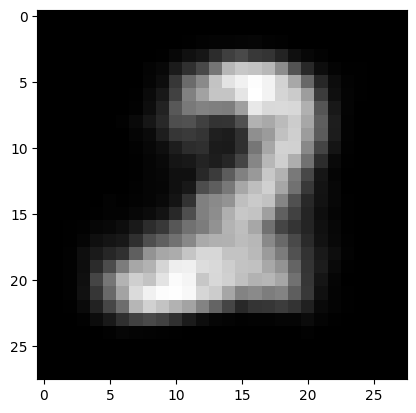

In [19]:
# Generate samples from the VAE
latent_vector = torch.randn((1, latent_dim)).to(device)
plt.imshow(vae.decoder(latent_vector).cpu().detach().numpy().squeeze(), cmap='gray')


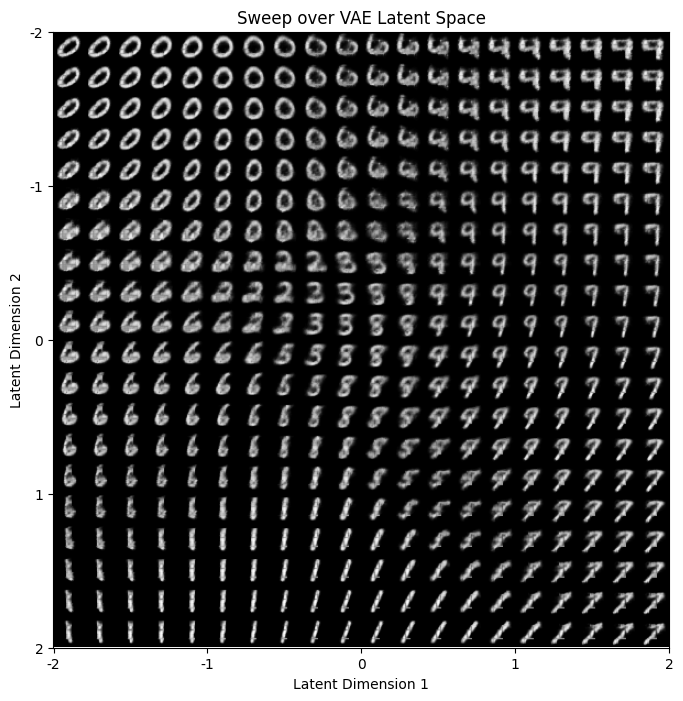

In [20]:
# Sweep over the first two dimensions of the latent space.
n = 20  # number of points per axis
extend = 2  # extent of the grid in each direction
grid_x = np.linspace(-extend, extend, n)
grid_y = np.linspace(-extend, extend, n)

figure = np.zeros((28 * n, 28 * n))

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z = torch.tensor([[xi, yi] + [0]*(latent_dim-2)], dtype=torch.float32).to(device)
        with torch.no_grad():
            x_decoded = vae.decode(z).cpu().numpy().squeeze()
        figure[i * 28: (i + 1) * 28,
               j * 28: (j + 1) * 28] = x_decoded

plt.figure(figsize=(8, 8))
plt.imshow(figure, cmap='gray')
plt.title('Sweep over VAE Latent Space')
plt.xticks(np.linspace(0, 28 * n, 5), [str(i) for i in np.linspace(-extend, extend, 5).astype(int)])
plt.yticks(np.linspace(0, 28 * n, 5), [str(i) for i in np.linspace(-extend, extend, 5).astype(int)])
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.show()

### Tasks
1. Compare the latent space of the VAE with that of the denoising autoencoder above. How do structure and distribution differ?
2. Compare sample quality when drawing random points in latent space for both models. Which performs better for generation, and why?
3. Remove the KL divergence term from the VAE loss and observe effects on the latent space, reconstructions, and samples. What does KL regularization contribute?
4. Experiment with different latent dimensions and find a trade-off between dimensionality and reconstruction quality.
